In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
import lightgbm as lgb

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
breast_cancer_df = pd.read_csv('breast_cancer_bd.csv')

In [3]:
breast_cancer_df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [4]:
# Ya saben nos gusta conocer las dimensiones de nuestro DataFrame
breast_cancer_df.shape

(699, 11)

In [5]:
# Se aplica el método info()
breast_cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample code number           699 non-null    int64 
 1   Clump Thickness              699 non-null    int64 
 2   Uniformity of Cell Size      699 non-null    int64 
 3   Uniformity of Cell Shape     699 non-null    int64 
 4   Marginal Adhesion            699 non-null    int64 
 5   Single Epithelial Cell Size  699 non-null    int64 
 6   Bare Nuclei                  699 non-null    object
 7   Bland Chromatin              699 non-null    int64 
 8   Normal Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [6]:
breast_cancer_df['Class'] = breast_cancer_df['Class'].astype(str)
breast_cancer_df['Bare Nuclei'] = breast_cancer_df['Bare Nuclei'].replace('?', np.nan)
breast_cancer_df = breast_cancer_df.dropna()

In [7]:
breast_cancer_df['Bare Nuclei'] = breast_cancer_df['Bare Nuclei'].astype(float)

In [8]:
breast_cancer_df.columns

Index(['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [9]:
nombres_bonitos = ["ID", "thickness", "size", "shape", "adhesion", "e_size", "b_nuclei", "chromatin", "n_nucleoli", "mitosis", "class"]

In [10]:
breast_cancer_df.columns = nombres_bonitos

In [11]:
breast_cancer_df.head()

,ID,thickness,size,shape,adhesion,e_size,b_nuclei,chromatin,n_nucleoli,mitosis,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


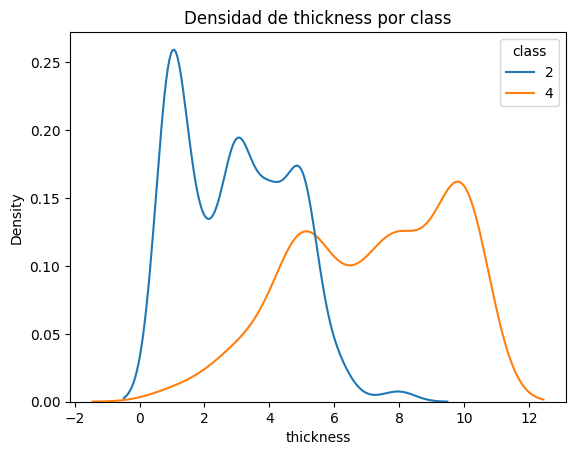

In [12]:
sns.kdeplot(data = breast_cancer_df, x='thickness', hue='class', common_norm=False)

plt.title("Densidad de thickness por class")
plt.show()

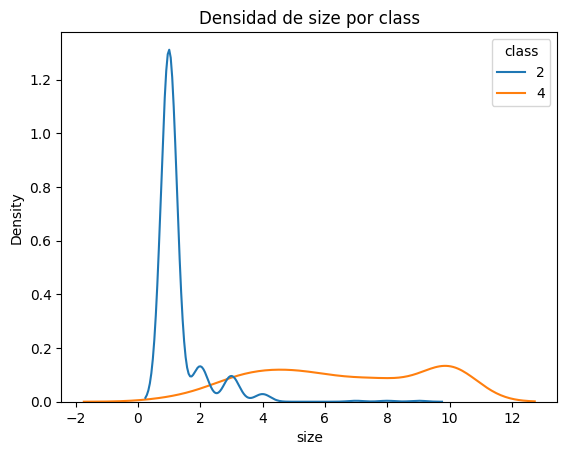

In [13]:
sns.kdeplot(data = breast_cancer_df, x='size', hue='class', common_norm=False)

plt.title("Densidad de size por class")
plt.show()

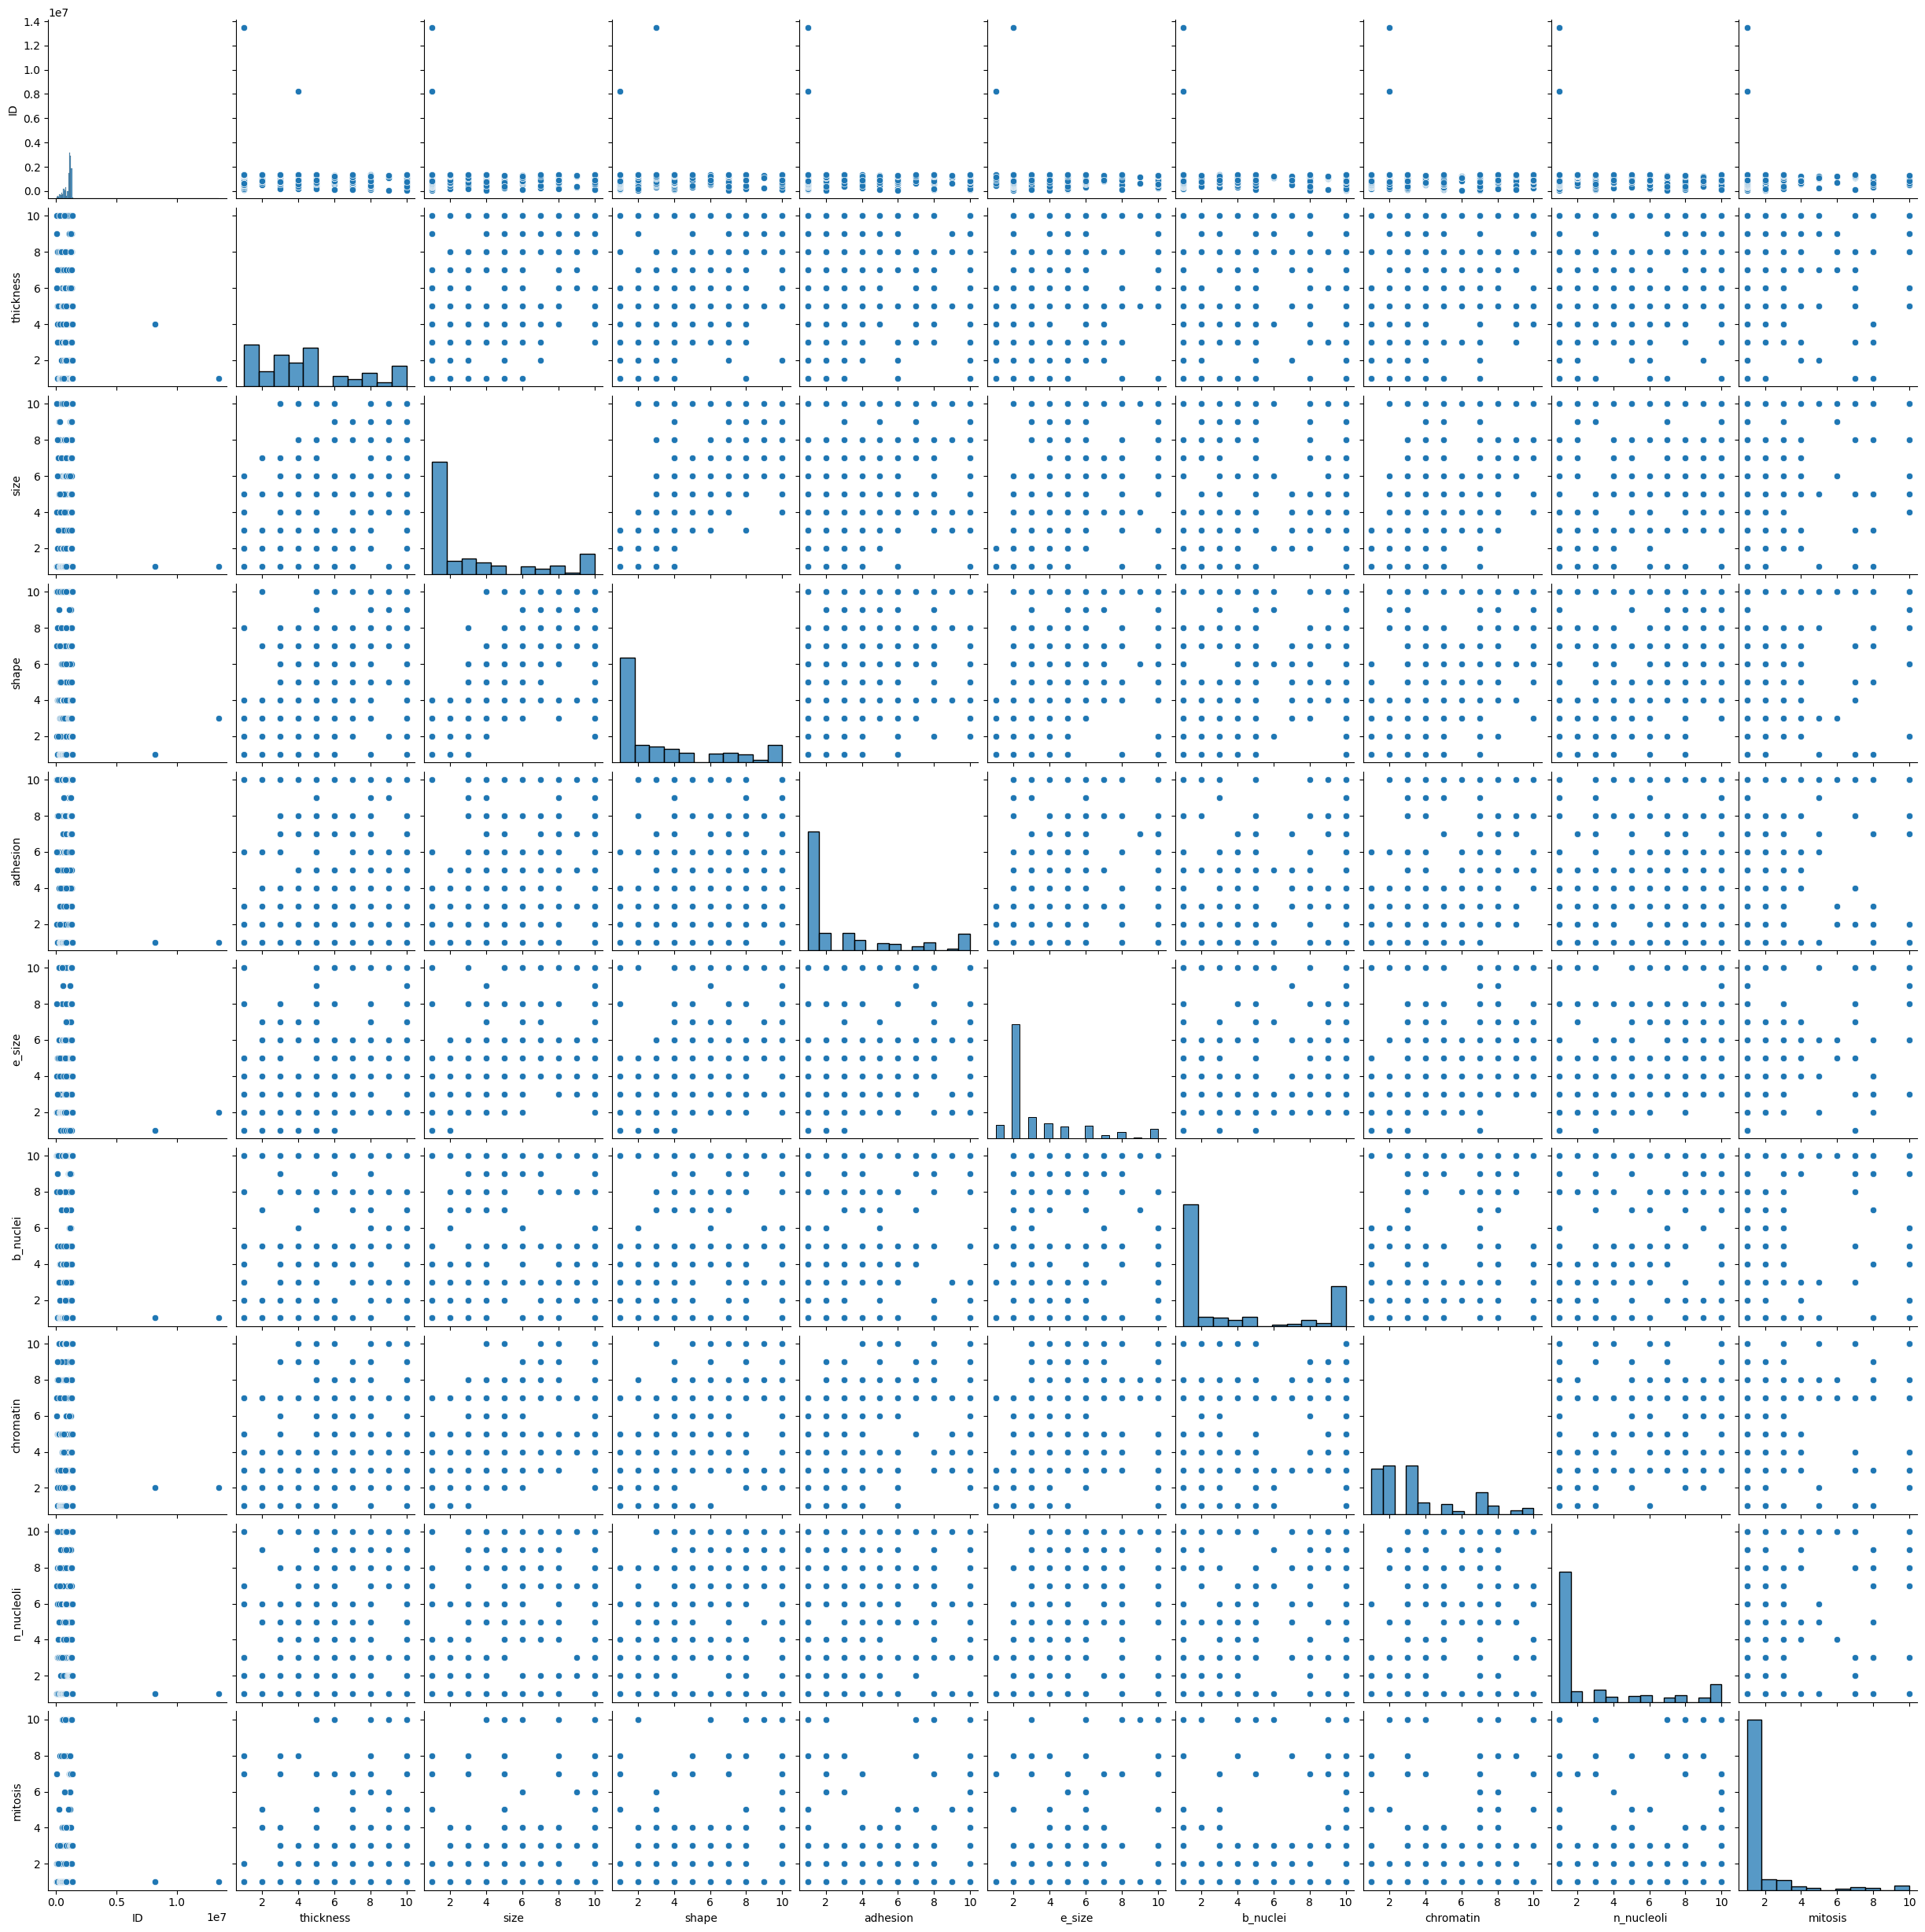

In [14]:
sns.pairplot(breast_cancer_df)

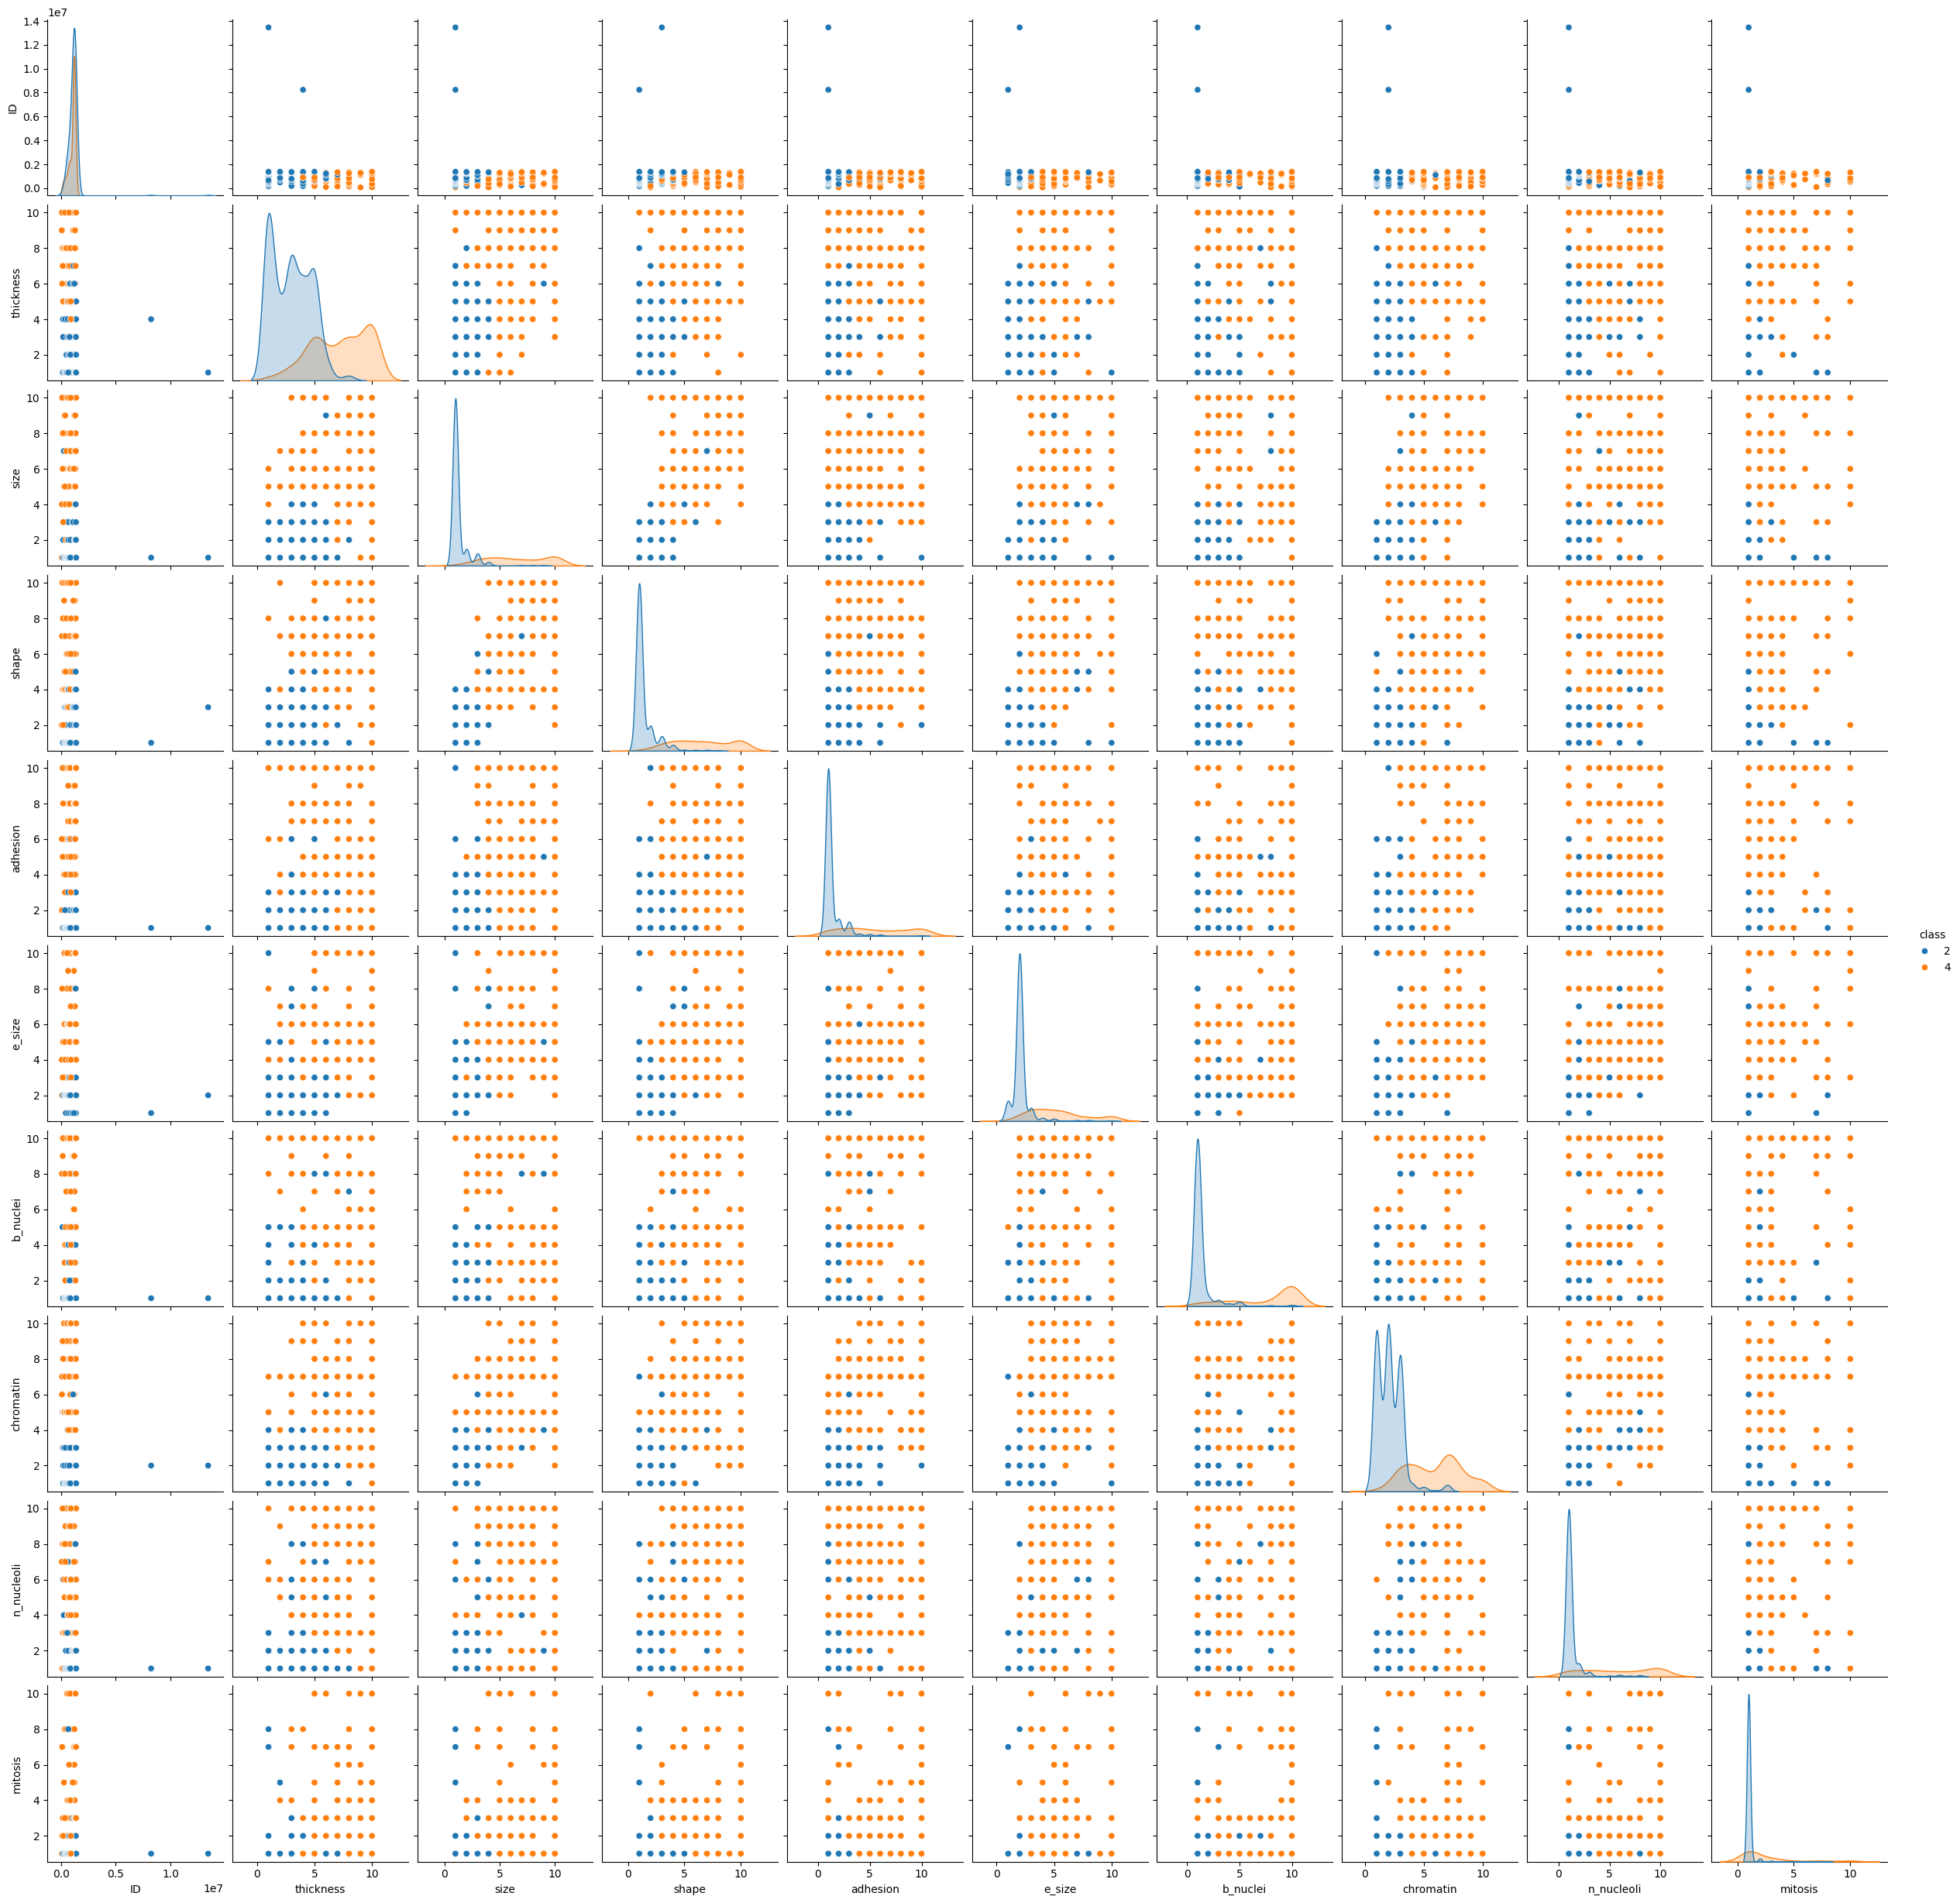

In [15]:
sns.pairplot(breast_cancer_df, hue="class")

## Aprendizaje supervisado: Clasificación

+ Definimos quién será la variable explicativa (en este casi la variable class que toma dos valores '2' y '4')

+ Usaremos el resto de las columnas, excepto el ID por supuesto, como variables explicativas.

In [16]:
# Se define la variable respuesta (y) y las variables explicativas (X)
y = breast_cancer_df['class']
variables_explicativas = ["thickness", "size", "shape", "adhesion", "e_size", "b_nuclei", "chromatin", "n_nucleoli", "mitosis"]
X = breast_cancer_df[variables_explicativas]

In [17]:
X.head()

,thickness,size,shape,adhesion,e_size,b_nuclei,chromatin,n_nucleoli,mitosis
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [18]:
# Hacemos la división train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

In [19]:
print(f"Tamaño del training set: {X_train.shape[0]}")
print(f"Tamaño de testing set: {X_test.shape[0]}")

Tamaño del training set: 546
Tamaño de testing set: 137


## Primer modelo: Un arbol sencillito con la configuración por default

In [20]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un árbol solito para un problema de clasificación (binaria)
modelo_arbol = DecisionTreeClassifier(random_state = 123)

# Entrenamos el modelo
modelo_arbol.fit(X_train, y_train)

# Obtenemos las predicciones del modelo sobre las observaciones de entrenamiento
y_pred_train = modelo_arbol.predict(X_train)
# Obtenemos las predicciones del modelo sobre las observaciones de test
y_pred_test = modelo_arbol.predict(X_test)

# Calculamos una métrica para problemas de clasificación: accuracy
# Porcentaje de observaciones que la predicción fue correcta
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 1.0
Accuracy en el dataset de prueba: 0.9416058394160584


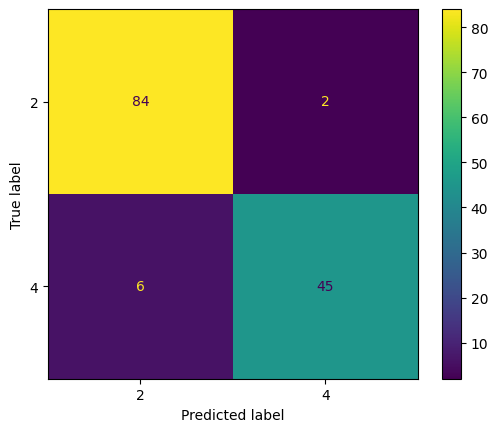

In [21]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

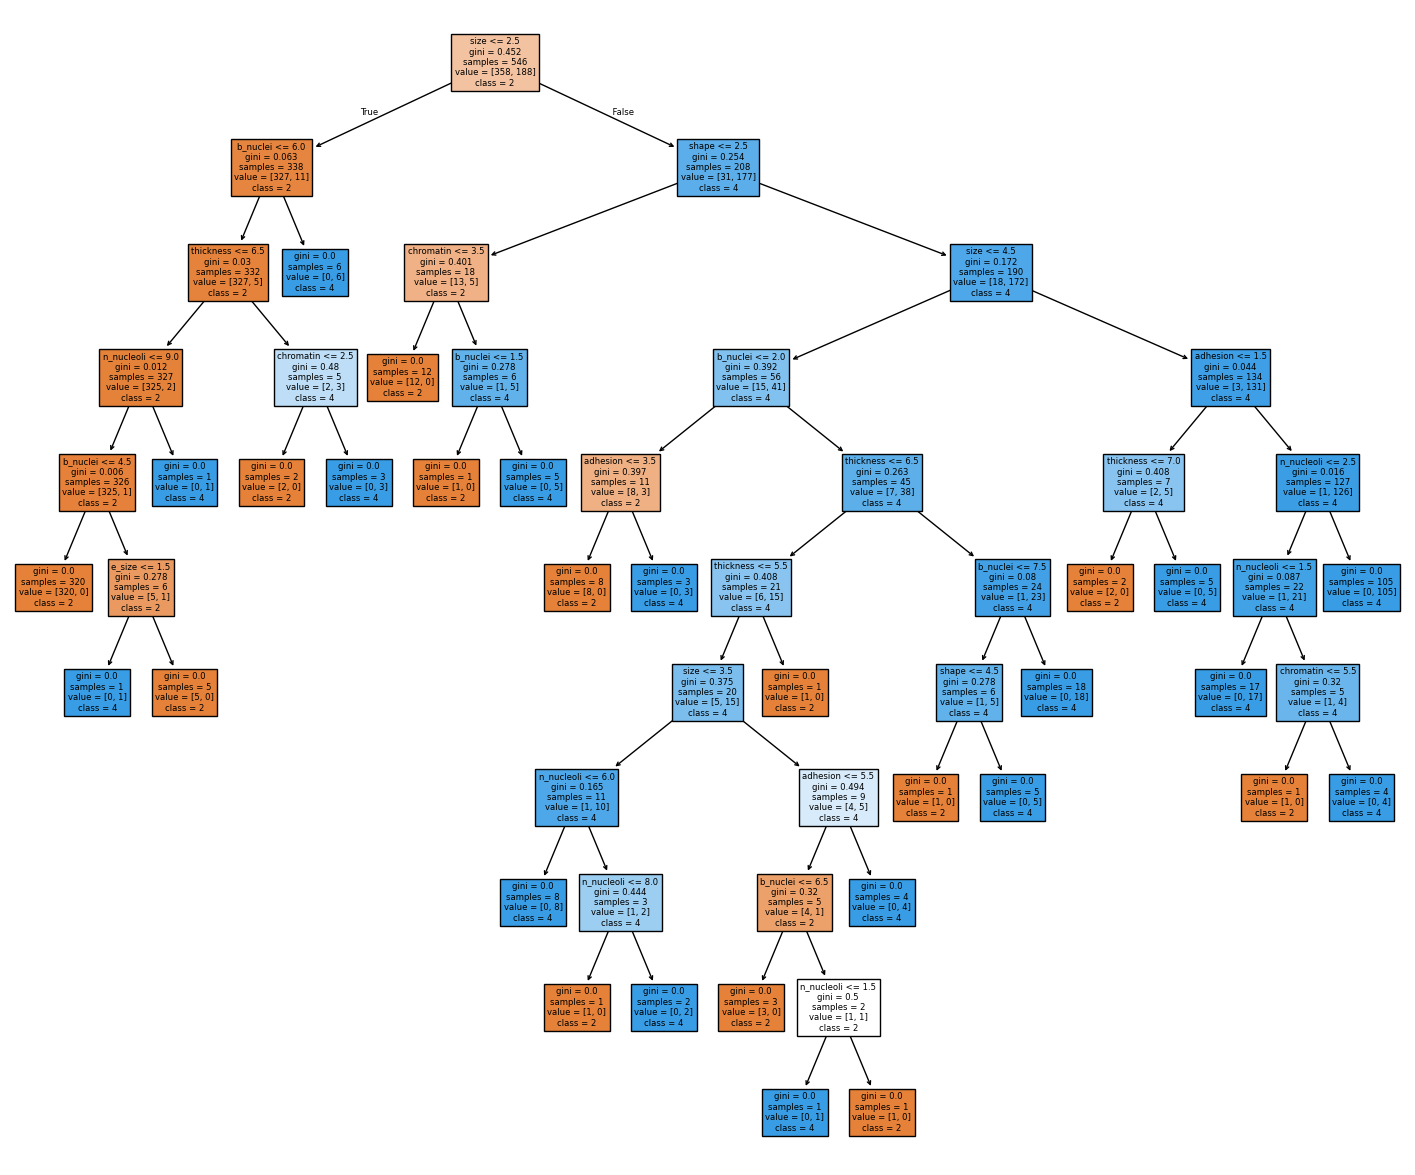

In [22]:
# Veamos una representación gráfica del modelo entrenado
plt.figure(figsize=(18, 15))
plot_tree(modelo_arbol, filled = True, feature_names = variables_explicativas,
          class_names = ['2','4'])
plt.show()

## Segundo modelo: Un modelo de bagging con 25 árboles

In [23]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un bagging para un problema de clasificación (binaria)
modelo_bagging = BaggingClassifier(
    estimator = DecisionTreeClassifier(),
    n_estimators = 25,
    max_samples = 5,
    bootstrap = True ,
    n_jobs=-1,
    random_state = 2026
)

modelo_bagging.fit(X_train, y_train)

y_pred_train = modelo_bagging.predict(X_train)
y_pred_test = modelo_bagging.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.9340659340659341
Accuracy en el dataset de prueba: 0.948905109489051


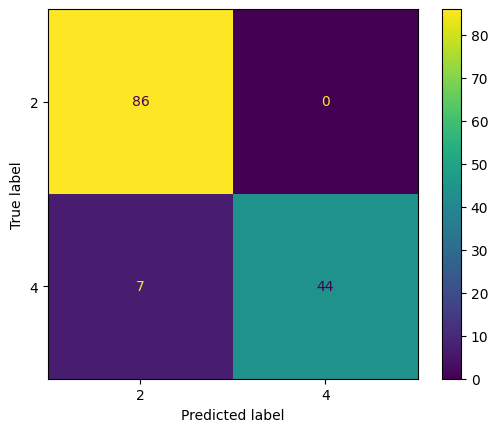

In [24]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

## Tercer modelo: Un random forest

In [25]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un random forest para un problema de clasificación (binaria)
modelo_rforest = RandomForestClassifier(
    n_estimators = 25,
    max_samples = 5,
    bootstrap = True ,
    n_jobs=-1,
    random_state = 2026
)

modelo_rforest.fit(X_train, y_train)

y_pred_train = modelo_rforest.predict(X_train)
y_pred_test = modelo_rforest.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.9395604395604396
Accuracy en el dataset de prueba: 0.9416058394160584


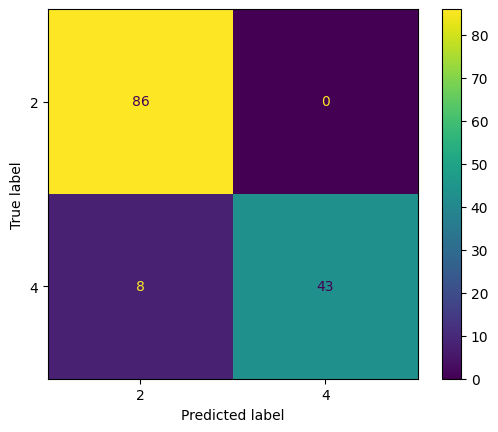

In [26]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

## Cuarto modelo: Un modelo de boosting con implementación gradiente

In [27]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un boosting para un problema de clasificación (binaria)
# Con una implemetación tipo gradiente
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)

gradient_booster.fit(X_train, y_train)

y_pred_train = gradient_booster.predict(X_train)
y_pred_test = gradient_booster.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 1.0
Accuracy en el dataset de prueba: 0.9708029197080292


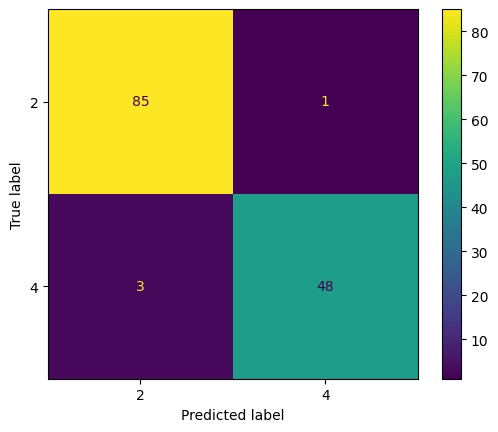

In [28]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

## Quinto Modelo: Un modelo de boosting con implementación AdaBoost

In [29]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un boosting para un problema de clasificación (binaria)
# Con una implemetación tipo AdaBoost
ada_booster = AdaBoostClassifier(learning_rate=0.1)

ada_booster.fit(X_train, y_train)

y_pred_train = ada_booster.predict(X_train)
y_pred_test = ada_booster.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 0.9633699633699634
Accuracy en el dataset de prueba: 0.9854014598540146


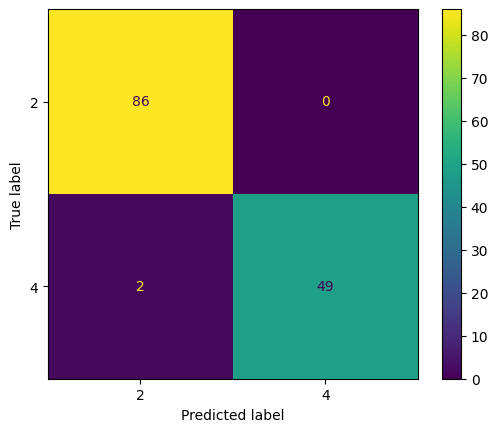

In [30]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

## Sexto modelo: Un modelo de boosting con implementación de histograma

In [31]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un boosting para un problema de clasificación (binaria)
# Con una implemetación tipo Histograma
modelo_boosting = HistGradientBoostingClassifier()

modelo_boosting.fit(X_train, y_train)

y_pred_train = modelo_boosting.predict(X_train)
y_pred_test = modelo_boosting.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")

Accuracy en el dataset de entrenamiento: 1.0
Accuracy en el dataset de prueba: 0.9854014598540146


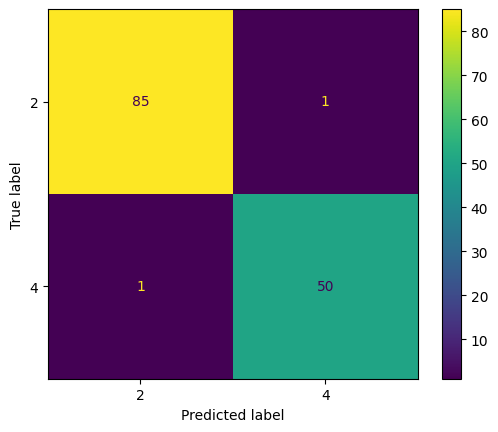

In [32]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

## Séptimo modelo: Un modelo de boosting con implementación de Light GB

In [33]:
# Le decimos a Python qué clase de modelo usaremos
# En este caso un boosting para un problema de clasificación (binaria)
# Con una implemetación tipo Light Gradient Boosting
modelo_lgb = lgb.LGBMClassifier(objective='binary', n_estimators=100)

modelo_lgb.fit(X_train, y_train)

y_pred_train = modelo_lgb.predict(X_train)
y_pred_test = modelo_lgb.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en el dataset de entrenamiento: {accuracy_train}")
print(f"Accuracy en el dataset de prueba: {accuracy_test}")


[LightGBM] [Info] Number of positive: 188, number of negative: 358
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 546, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.344322 -> initscore=-0.644091
[LightGBM] [Info] Start training from score -0.644091
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

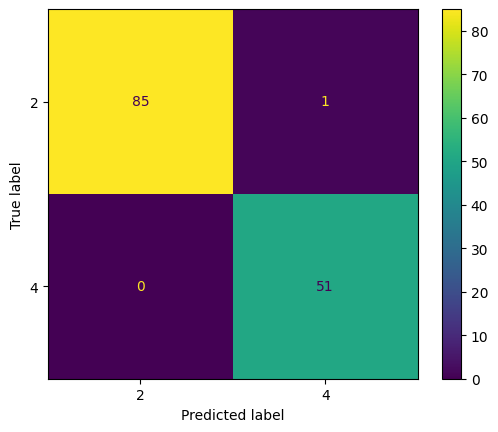

In [34]:
# Se obtiene la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)

# Se obtiene una representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['2','4'])
disp.plot()
plt.show()

# Grid Search

+ Hasta ahorita hemos utilizado varias familas de modelos con una configuración muy sencillita

+ Vamos a seleccionar el mejor modelo dentro de una familia de modelos

+ Empezaremos con un árbol sencillito

In [35]:
# Empezaremos definiendo varias posibles configuraciones para los hiper-parámetros del modelo de árbol
param_grid = {
    'max_depth': range(1, 10, 1), # Profundidad del árbol
    'min_samples_leaf': range(1, 20, 2), # Detente cuando las hojas tengan este tamaño
    'min_samples_split': range(2, 20, 2), # Detente si los nodos tendrían menos de este tamaño
    'criterion': ["entropy", "gini"] # Criterio de pureza
}

# Usaremos un modelo de árbol para clasificación
modelo_arbol = DecisionTreeClassifier(random_state = 123)

In [36]:
# Haremos un 5-fold cross-validation
grid_search = GridSearchCV(estimator = modelo_arbol,
                           param_grid = param_grid,
                           cv = 5, verbose = True)

In [37]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=123),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 20, 2),
                         'min_samples_split': range(2, 20, 2)},
             verbose=True)

In [38]:
# De todas las combinaciones que hicimos, imprimimos la que tiene el mejor score
grid_search.best_score_

np.float64(0.9561134278565472)

In [39]:
# Nos quedamos con el árbol con la mejor combinación de hiper-parámetros
mejor_arbol = grid_search.best_estimator_

In [40]:
mejor_arbol

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=5,
                       random_state=123)

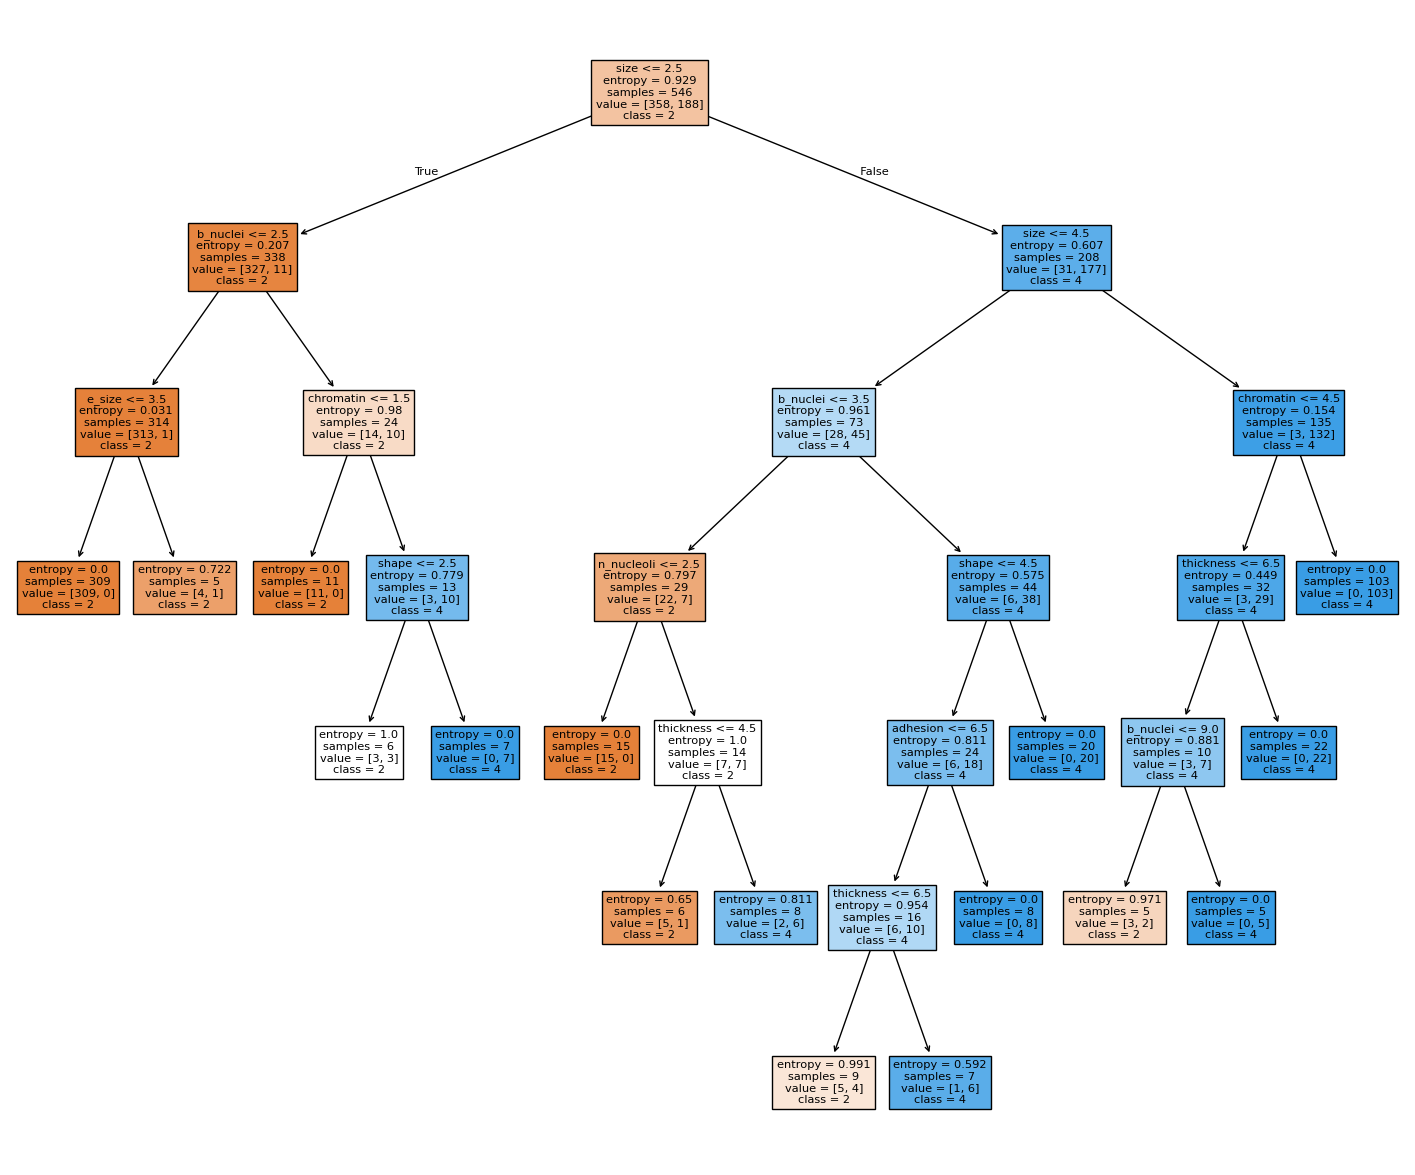

In [41]:
plt.figure(figsize=(18, 15))
plot_tree(mejor_arbol, filled = True, feature_names = variables_explicativas,
          class_names = ['2','4'])
plt.show()